# Rules Extraction for Knowledge Base Using Decision Trees.

In [174]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn import tree as sklearn_tree

rd_seed = 42

## Dataset Preparation



We use Breast Cancer Wisconsin (Diagnostic) dataset, which can be downloaded here: [Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data?resource=download)

Version of the dataset: 2

In [23]:
df = pd.read_csv('data.csv')

### Dataset split

Before even looking at data, we will split it into train-test sets:

In [24]:
print(f'Dataset size: {len(df)}')

Dataset size: 569


The dataset is small, thus, when splitting data we need test set larger. Also, using cross validation is highly important.

We will split dataset into 70%-30%

In [39]:
df_train, df_test = train_test_split(df, train_size=0.7, random_state=rd_seed)
print(f'Train shape: {df_train.shape}')
print(f'Test shape: {df_test.shape}')

Train shape: (398, 33)
Test shape: (171, 33)


After split we can inspect data in the `df_train`, figure out all transformations on df_train and create transformation function.

### First look on the data:

In [26]:
df_train.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
149,869931,B,13.74,17.91,88.12,585.0,0.07944,0.06376,0.02881,0.01329,...,22.46,97.19,725.9,0.09711,0.1824,0.1564,0.06019,0.2350,0.07014,NaN
124,865468,B,13.37,16.39,86.10,553.5,0.07115,0.07325,0.08092,0.02800,...,22.75,91.99,632.1,0.10250,0.2531,0.3308,0.08978,0.2048,0.07628,NaN
421,906564,B,14.69,13.98,98.22,656.1,0.10310,0.18360,0.14500,0.06300,...,18.34,114.10,809.2,0.13120,0.3635,0.3219,0.11080,0.2827,0.09208,NaN
195,875878,B,12.91,16.33,82.53,516.4,0.07941,0.05366,0.03873,0.02377,...,22.00,90.81,600.6,0.10970,0.1506,0.1764,0.08235,0.3024,0.06949,NaN
545,922576,B,13.62,23.23,87.19,573.2,0.09246,0.06747,0.02974,0.02443,...,29.09,97.58,729.8,0.12160,0.1517,0.1049,0.07174,0.2642,0.06953,NaN


There is the column `Unnamed: 32`, which has ony `nan` values. We will remove this column, because it has no value for us.

In [27]:
df_train_modified = df_train.drop(['Unnamed: 32'], axis=1)

In [13]:
df_train_modified.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, 149 to 102
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       398 non-null    int64  
 1   diagnosis                398 non-null    object 
 2   radius_mean              398 non-null    float64
 3   texture_mean             398 non-null    float64
 4   perimeter_mean           398 non-null    float64
 5   area_mean                398 non-null    float64
 6   smoothness_mean          398 non-null    float64
 7   compactness_mean         398 non-null    float64
 8   concavity_mean           398 non-null    float64
 9   concave points_mean      398 non-null    float64
 10  symmetry_mean            398 non-null    float64
 11  fractal_dimension_mean   398 non-null    float64
 12  radius_se                398 non-null    float64
 13  texture_se               398 non-null    float64
 14  perimeter_se             398 

- Almost all of the features are numeric.
- There are no missing values in the train data. In reality our classifier may get some missing values, that should be handled. But for simplification reasons for this task we will assume that there will be no missing values in the test set and in model usage.

In [28]:
df_t_m_nunique = pd.DataFrame(df_train_modified.nunique(), columns=['Number of unique values'])
df_t_m_nunique['Uniqueness ratio'] = np.round(df_t_m_nunique['Number of unique values'] / len(df), 3)
df_t_m_nunique.T

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
Number of unique values,398.000,2.000,338.000,349.000,375.000,380.000,346.000,380.000,387.00,384.000,...,334.000,361.000,367.000,383.000,316.000,378.000,383.000,350.000,368.000,380.000
Uniqueness ratio,0.699,0.004,0.594,0.613,0.659,0.668,0.608,0.668,0.68,0.675,...,0.587,0.634,0.645,0.673,0.555,0.664,0.673,0.615,0.647,0.668


Almost all numeric features have high uniqueness ratio.

Also let's look at some stats of the numeric features:

In [30]:
df_train_modified.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,3.980000e+02,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,...,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,3.012241e+07,14.176078,19.159171,92.256332,659.770854,0.095962,0.103303,0.088071,0.048440,0.180308,...,16.287322,25.505553,107.363844,881.848241,0.131772,0.249086,0.268497,0.113839,0.288300,0.083537
std,1.270358e+08,3.535730,4.214074,24.289529,358.865452,0.013766,0.051209,0.077836,0.037712,0.026871,...,4.799691,6.017564,33.083204,570.753903,0.023023,0.148622,0.196139,0.063886,0.062318,0.017518
min,8.915000e+03,7.691000,9.710000,48.340000,170.400000,0.062510,0.019380,0.000000,0.000000,0.116700,...,8.678000,12.020000,54.490000,223.600000,0.081250,0.034320,0.000000,0.000000,0.156500,0.055040
25%,8.682072e+05,11.752500,16.170000,75.805000,426.175000,0.085550,0.063407,0.029585,0.020692,0.161575,...,13.075000,21.070000,84.542500,521.550000,0.114325,0.147325,0.116475,0.063885,0.247775,0.071155
50%,9.053455e+05,13.275000,18.700000,85.980000,546.250000,0.094625,0.091280,0.061880,0.034110,0.178800,...,14.975000,25.155000,97.745000,687.600000,0.131150,0.209250,0.226200,0.099270,0.280750,0.080165
75%,8.813066e+06,16.090000,21.555000,105.625000,797.400000,0.104475,0.130575,0.127075,0.073963,0.195550,...,18.707500,29.410000,125.300000,1061.250000,0.146000,0.341600,0.384700,0.160400,0.315650,0.091745
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.311400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.218400,0.937900,0.903400,0.275600,0.663800,0.173000


We see that features are scaled differently. But for the decision trees scaling - like standardization or normalization are no necessary. Scaling will only reduce interpretability of the model, because the decision threshold values will be scaled too and thus it will be hard to interpret them in regard to original data.

Last thing we want to examine how our data is balanced:

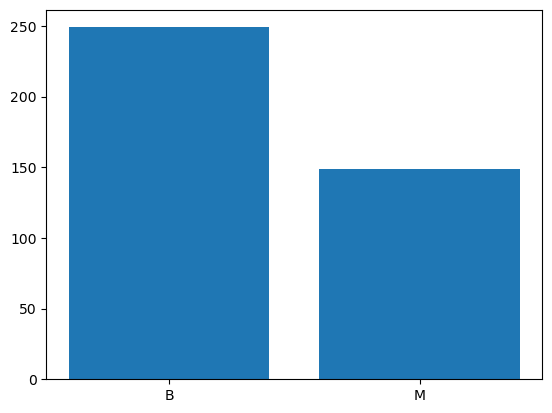

In [49]:
fig, ax = plt.subplots()
_ = ax.bar(x=df_train['diagnosis'].unique(),
           height=df_train['diagnosis'].value_counts())


In [60]:
df_t_diagnosis_vc = pd.DataFrame(df_train['diagnosis'].value_counts())
df_t_diagnosis_vc['count ratio (%)'] = np.round(df_t_diagnosis_vc['count'] / len(df_train) * 100, 2)
df_t_diagnosis_vc

,count,count ratio (%)
diagnosis,,
B,249,62.56
M,149,37.44


From the train set we see that there is some imbalance. Some up-sampling or under-sampling may make situation a little bit better, but for simplification, we will ignore such methods, as well as other dataset modifications to solve this issue.

But in training, we will use AUC score as a baseline metric. Additionally, we will also track F1 score and Accuracy.

### Data Transformation

In this section we will:
- make `diagnosis` label as category type
- create transformation function to separate class from features and make other transformations we did earlier.

In [99]:
def transform_and_split_data(dataframe) -> tuple[pd.DataFrame, pd.Series]:
    diagnosis_category = pd.api.types.CategoricalDtype(dataframe['diagnosis'].unique())
    dataframe['diagnosis'] = dataframe['diagnosis'].astype(diagnosis_category)
    dataframe_dropped = dataframe.drop(['id', 'Unnamed: 32'], axis=1)
    y_data = dataframe_dropped['diagnosis'].cat.codes
    X_data = dataframe_dropped.drop(['diagnosis'], axis=1)
    return X_data, y_data

In [100]:
X_train, y_train = transform_and_split_data(df_train)
X_test, y_test = transform_and_split_data(df_test)

Now our data is prepared for training.

## Model Training - Random Forest Decision Trees

We will try to train the best Random Forest with Decision Tree classifier:
- we will use cross validation to avoid great/poor fit by chance
- we will use randomized hyperparameter choice for faster training

### Training

For this task we will use very basic hyperparameters:

In [70]:
hyperparameters = {
    'n_estimators': np.append([1], np.arange(5, 105, 5)),
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(1, 31, 1),
}

In [71]:
param_grid = ParameterGrid(hyperparameters)
print('Number of hyperparameters: {}'.format(len(param_grid)))

Number of hyperparameters: 1260


We will do 100 random iterations, picking random parameters from the hyperparameter space. Because we have parameters as list and not as distributions, sampling without replacement will be used.

In [140]:
scoring = {'AUC': make_scorer(roc_auc_score),
           'Accuracy': make_scorer(accuracy_score),
           'F1_score': make_scorer(f1_score)}
hparam_search = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=hyperparameters,
                                   random_state=rd_seed, scoring=scoring, refit='AUC', n_iter=100)

In [141]:
results = hparam_search.fit(X_train, y_train)

In [142]:
results

RandomizedSearchCV(estimator=RandomForestClassifier(), n_iter=100,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]),
                                        'n_estimators': array([  1,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100])},
                   random_state=42, refit='AUC',
                   scoring={'AUC': make_scorer(roc_auc_score, response_method='predict'),
                            'Accuracy': make_scorer(accuracy_score, response_method='predict'),
                            'F1_score': make_scorer(f1_score, response_method='predict')})

In [143]:
best_hparam_idx = np.argmax(results.cv_results_['mean_test_AUC'])
print(f'Best model hyperparameters (validation): {results.cv_results_["params"][best_hparam_idx]}')
print(f'Best model AUC score (validation): {results.cv_results_["mean_test_AUC"][best_hparam_idx]:.3f}')
print(f'Best model F1 score (validation): {results.cv_results_["mean_test_F1_score"][best_hparam_idx]:.3f}')
print(f'Best model Accuracy (validation): {results.cv_results_["mean_test_Accuracy"][best_hparam_idx]:.3f}')

Best model hyperparameters (validation): {'n_estimators': 60, 'max_depth': 20, 'criterion': 'gini'}
Best model AUC score (validation): 0.960
Best model F1 score (validation): 0.952
Best model Accuracy (validation): 0.965


### Model Evaluation
Now we will train model with best hyperparameters on whole train set and evaluate it on the test set.

The final model will be used for model extraction.

In [144]:
best_hparams = results.best_params_
print(f'Best parameters: ', best_hparams)

Best parameters:  {'n_estimators': 60, 'max_depth': 20, 'criterion': 'gini'}


In [145]:
best_model = RandomForestClassifier(**best_hparams, random_state=rd_seed)
best_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=60, random_state=42)

In [146]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

scoring = {
    'AUC': roc_auc_score(y_test, y_pred_proba),
    'F1_score': f1_score(y_test, y_pred),
    'Accuracy': accuracy_score(y_test, y_pred)

}


In [147]:
for metric, value in scoring.items():
    print(f"Test set {metric}: {value:.3f}")

Test set AUC: 0.997
Test set F1_score: 0.959
Test set Accuracy: 0.971


We see that on test set we have better metrics than on the cross validation. We can assume that on other test data our model will perform with similar performance as on the cross validation, if not slightly better.

### Rules Evaluation
Now we have extract rules from our random forest.


We have 60 trees in our best model, with max depth of 20. The model will have quite a lot of rules, making its interpretability very complex.

#### Examining Sklearn Trees Structure
In order to extract something from the trees, we have to understand how to work with sklearn tree structure in the first place.


Documentation resources can be found here:
- [Decision Tree Classifier](https://scikit-learn.org/1.5/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [Tree Structure](https://scikit-learn.org/1.5/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py)

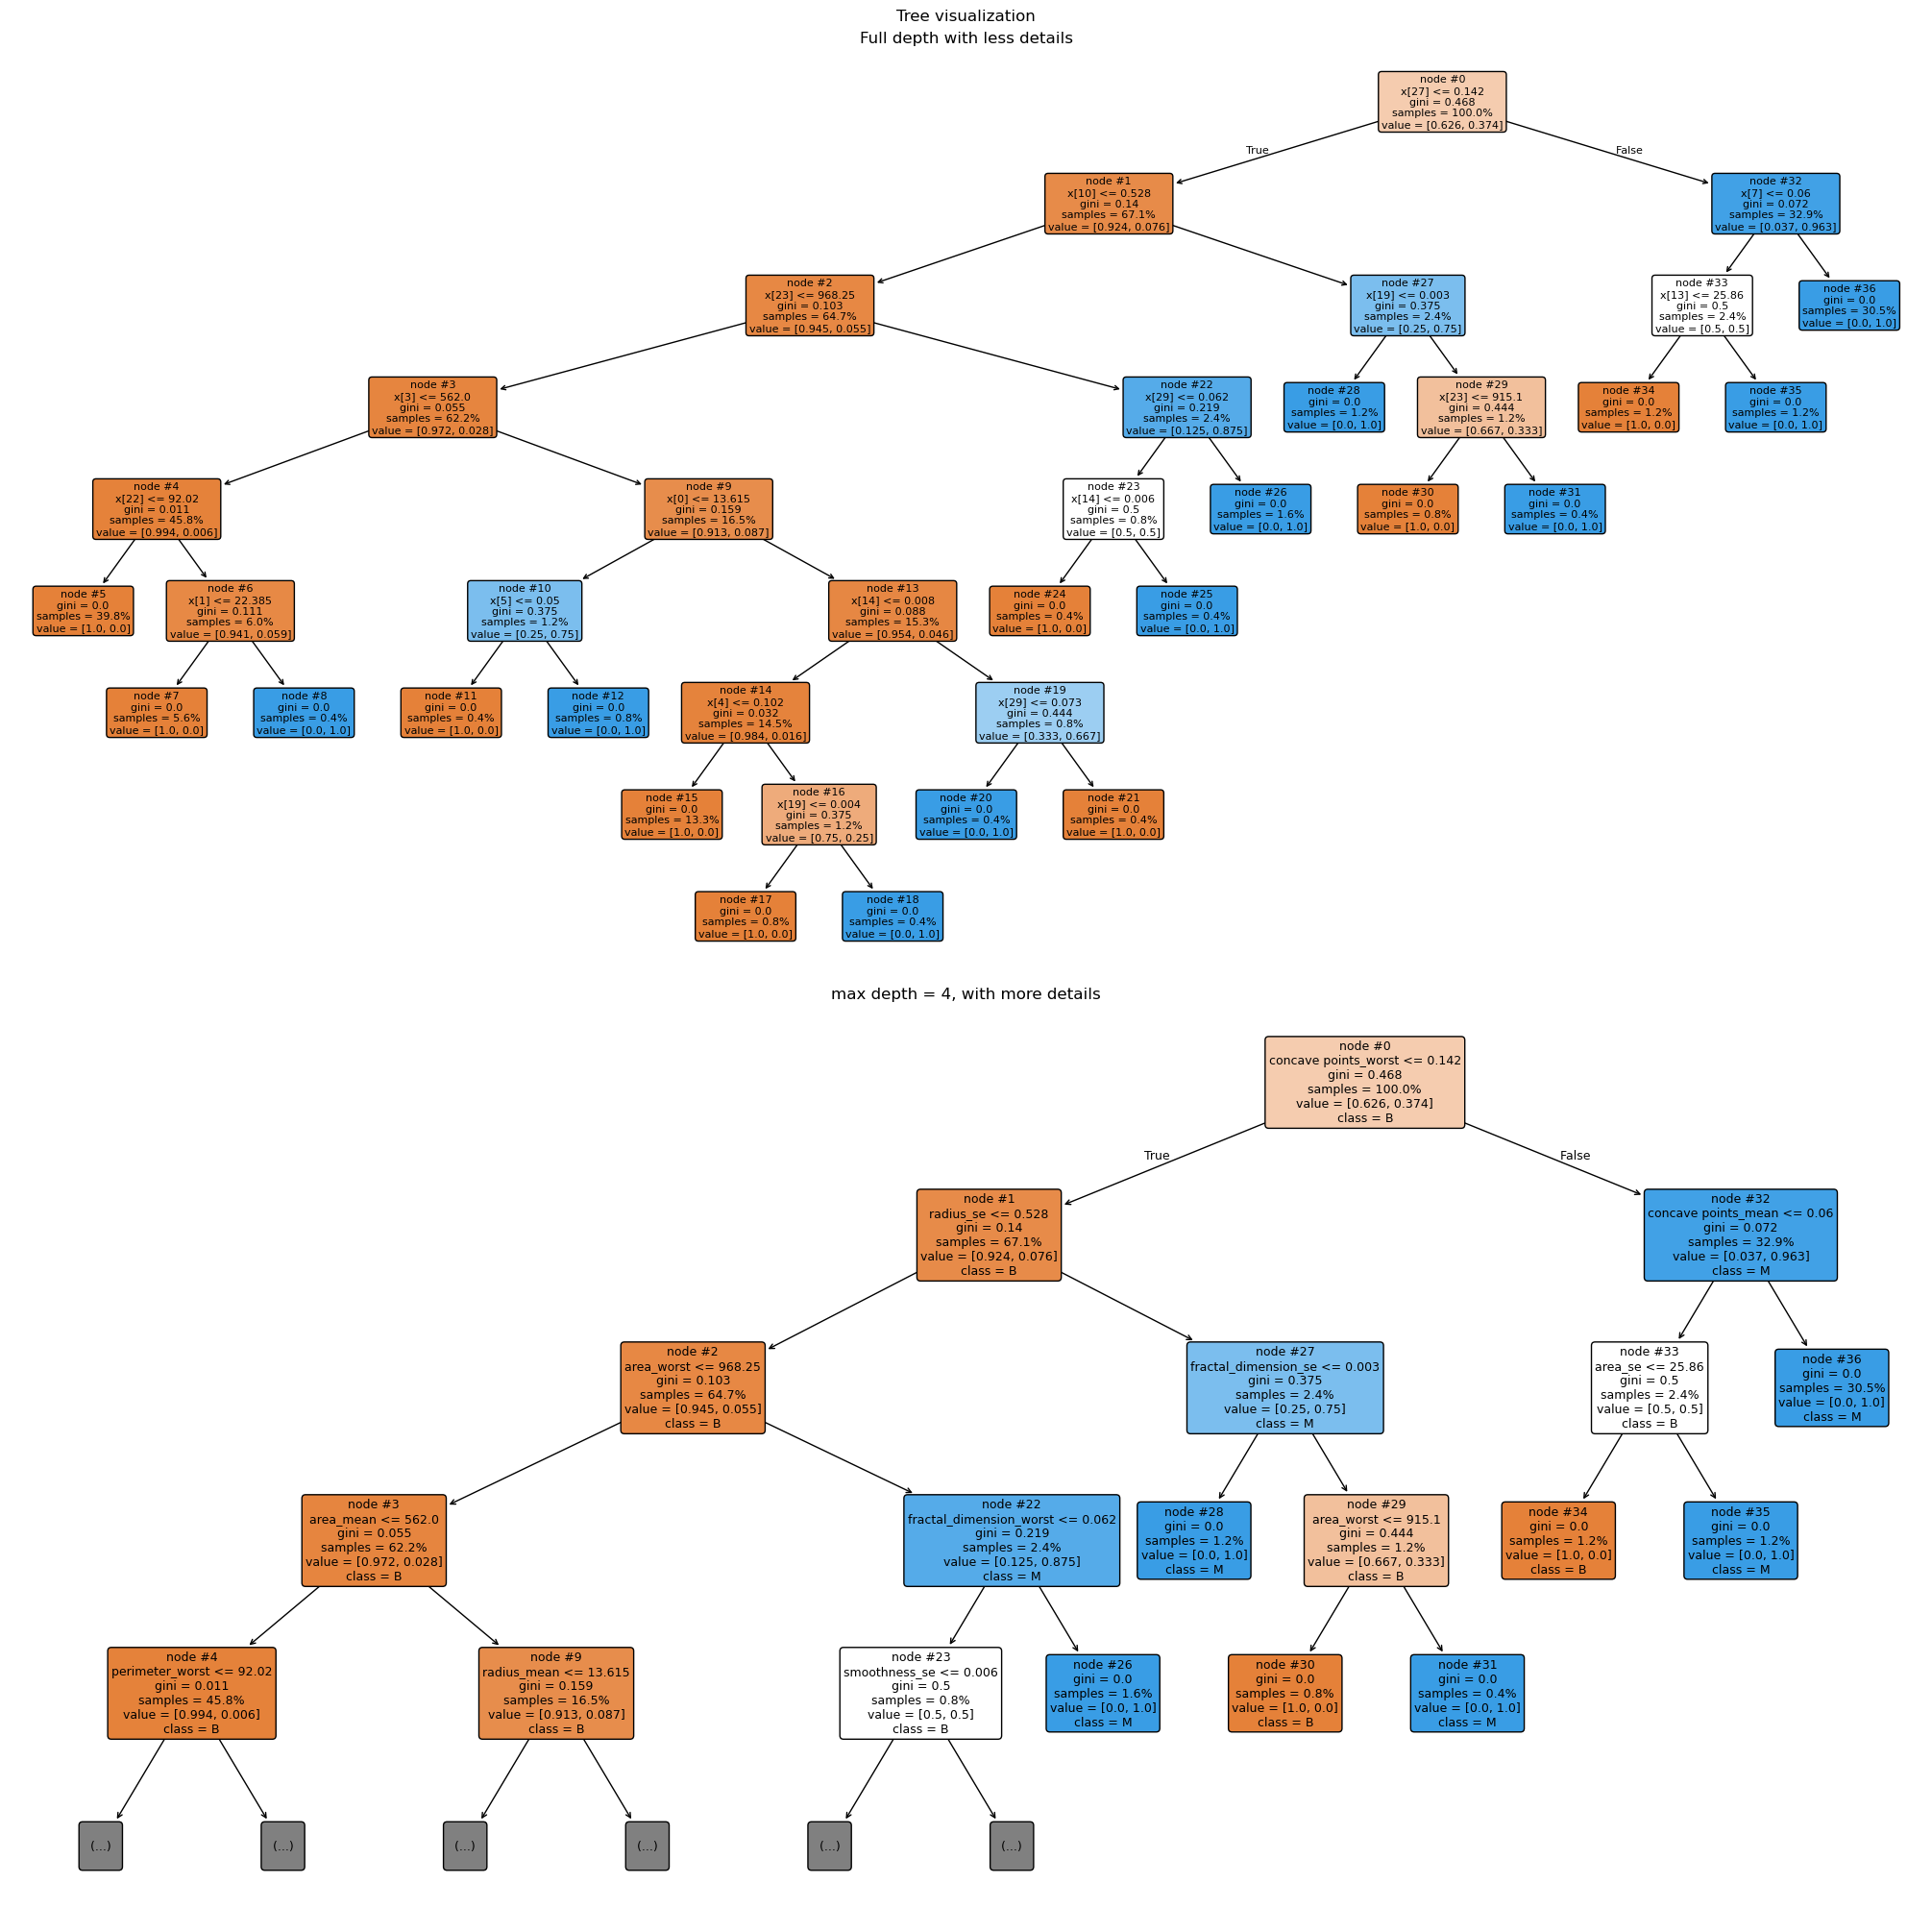

In [227]:
estimators = best_model.estimators_
tree = estimators[0]
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 20), constrained_layout=True)
# bigger tree
ax_bigger_tree_plot = axes[0]
sklearn_tree.plot_tree(tree,
                           node_ids=True,
                           filled=True,
                           proportion=True,
                           rounded=True,
                           fontsize=8,
                           ax=ax_bigger_tree_plot)
ax_bigger_tree_plot.set_title('Full depth with less details')

# smaller tree with more details
ax_smaller_tree_plot = axes[1]
sklearn_tree.plot_tree(tree,
                           max_depth=4,
                           feature_names=X_train.columns,
                           class_names=df_train['diagnosis'].unique(),
                           node_ids=True,
                           filled=True,
                           proportion=True,
                           rounded=True,
                           fontsize=9,
                           ax=ax_smaller_tree_plot)
ax_smaller_tree_plot.set_title('max depth = 4, with more details')
_ = fig.suptitle('Tree visualization')

Nodes have indexes. Root index is 0.

From documentation we can access node information using these functions:

> - `children_left[i]`: id of the left child of node i or -1 if leaf node
> - `children_right[i]`: id of the right child of node i or -1 if leaf node
> - `feature[i]`: feature used for splitting node i
> - `threshold[i]`: threshold value at node i
> - `n_node_samples[i]`: the number of training samples reaching node i
> - `impurity[i]`: the impurity at node i
> - `weighted_n_node_samples[i]`: the weighted number of training samples reaching node i
> - `value[i, j, k]`: the summary of the training samples that reached node i for output j and class k (for regression tree, class is set to 1). See below for more information about value.

Extraction of all information of the node 0:

In [240]:
node_id = 0
classes = df_train['diagnosis'].unique()
print(f'node #{node_id}')
print(f'{X_train.columns[tree.tree_.feature[node_id]]} <= {tree.tree_.threshold[node_id]}')
print(f'gini = {tree.tree_.impurity[node_id]}')
print(f'samples = {tree.tree_.n_node_samples[node_id]}')
value = np.squeeze(tree.tree_.value[0])
print(f'value = {value}')
print(f'class = {np.argmax(value)} ({classes[np.argmax(value)]})')
print(f'is split node = {tree.tree_.children_left[node_id] != tree.tree_.children_right[node_id]}')

node #0
concave points_worst <= 0.14239999651908875
gini = 0.4684351405267544
samples = 249
value = [0.62562814 0.37437186]
class = 0 (B)
is split node = True


If we have a leaf node, both left and right child are `-1`:

In [246]:
node_id = 5
print(f'Node #{node_id} (leaf node) left child: {tree.tree_.children_left[node_id]}')
print(f'Node #{node_id} (leaf node) right child: {tree.tree_.children_right[node_id]}')

Node #5 (leaf node) left child: -1
Node #5 (leaf node) right child: -1


#### Extracting Rules From a Tree

In this section we will create an algorithm to extract all rules from a single tree.

We will traverse a tree using stack, and each time we get to a list, we generate a rule from the tree.

In [232]:
class RuleExtractionIterator:
    def __init__(self, decision_tree, feature_names, class_names):
        """
        IMPORTANT: the iterator doesn't check situation where the root node is a split node.
        The issue may arise when we get decision tree with a single node, which is both root and leaf,
        and doesn't have a threshold value.

        :param decision_tree: a trained DecisionTreeClassifier
        :param feature_names: list of feature names
        """
        self.tree = decision_tree.tree_
        if self.tree.node_count == 0:
            return
        self.children_left = self.tree.children_left
        self.children_right = self.tree.children_right
        self.features = self.tree.feature
        self.thresholds = self.tree.threshold
        self.values = self.tree.value
        self.feature_names = feature_names
        self.class_names = class_names

    def __iter__(self):
        # Stack for DFS: each element is (node_id, path_conditions)
        # path_conditions is a list of pairs (feature, threshold)
        if self.tree.node_count == 0:
            raise StopIteration
        root_condition = (self.features[0], self.thresholds[0])
        self.stack = [(0, [root_condition])]  # start at root
        return self

    def __next__(self):
        """
        Iteratively traverse the tree using a stack.
        When a leaf node is encountered, construct and return the rule.
        """
        while self.stack:
            node_idx, path_conditions = self.stack.pop()

            # Check if this is a leaf node
            left_child = self.children_left[node_idx]
            right_child = self.children_right[node_idx]

            if self.is_leaf_node(node_idx):
                # Determine the predicted class at this leaf
                # self.values[node_id] has shape (1, n_classes) for single-output classification
                class_values = self.values[node_idx][0]
                predicted_class_idx = np.argmax(class_values)
                predicted_class = self.class_names[predicted_class_idx]

                # Construct a rule of the form IF cond1 & cond2 & ... THEN class
                if path_conditions:
                    rule_body = " & ".join(path_conditions)
                else:
                    rule_body = "TRUE"  # Root is a leaf => no conditions

                rule = f"IF {rule_body} THEN {predicted_class}"
                return rule
            else:
                # Not a leaf => push its children onto the stack with updated path conditions

                # Condition for the left child (<= threshold)
                feature_idx = self.feature[node_idx]
                threshold_val = self.threshold[node_idx]
                left_condition = f"{self.feature_names[feature_idx]} <= {threshold_val:.4f}"

                # Condition for the right child (> threshold)
                right_condition = f"{self.feature_names[feature_idx]} > {threshold_val:.4f}"

                # Add child nodes to stack
                # Note: We push the right child first so that the left child is popped next (DFS order).
                self.stack.append(
                    (right_child, path_conditions + [right_condition])
                )
                self.stack.append(
                    (left_child, path_conditions + [left_condition])
                )

        # If the stack is empty, we've traversed all leaves => no more rules
        raise StopIteration

    def is_leaf_node(self, node_idx) -> bool:
        """Leaf detection in sklearn (both children are -1)"""
        return self.children_left[node_idx] == -1 and self.children_right[node_idx] == -1


0.4684351405267544

In [233]:
tree.tree_.threshold[0]

0.14239999651908875

### What can be improved


- Understand dataset domain to make better data preprocessing using some domain knowledge, than just following numbers.
- Handle potential problems with data imbalance.
- Handle potential problems with missing values in input data in production.
- In hyperparameter search, try to use distributions skewed to lower amounts of estimators and max depth (or at least max depth, to make rule more interpretable) to sample trees that are more interpretable, so the rules are also interpretable.
- The RuleExtractionIterator doesn't check situation when root node isn't a split node, and thus do not have a threshold.